# Import Library dan Membaca Dataset

Pada tahap ini dilakukan import library yang diperlukan untuk analisis data serta membaca dataset training dan testing menggunakan pandas.

In [32]:
import pandas as pd
import numpy as np
train = pd.read_csv('data_training.csv')
test = pd.read_csv('data_testing.csv')

# Menampilkan Dataset

Tahap ini dilakukan untuk melihat struktur awal dataset training dan testing.

In [33]:
train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


In [34]:
test.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516


# Informasi Dataset

Dilakukan pengecekan jumlah data, tipe data, dan kelengkapan data pada masing-masing variabel.

In [35]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


In [36]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         286 non-null    float64
 1   volatile acidity      286 non-null    float64
 2   citric acid           286 non-null    float64
 3   residual sugar        286 non-null    float64
 4   chlorides             286 non-null    float64
 5   free sulfur dioxide   286 non-null    float64
 6   total sulfur dioxide  286 non-null    float64
 7   density               286 non-null    float64
 8   pH                    286 non-null    float64
 9   sulphates             286 non-null    float64
 10  alcohol               286 non-null    float64
 11  Id                    286 non-null    int64  
dtypes: float64(11), int64(1)
memory usage: 26.9 KB


In [37]:
print("Ukuran data training:", train.shape)
print("Ukuran data testing:", test.shape)

Ukuran data training: (857, 13)
Ukuran data testing: (286, 12)


# Pengecekan Missing Value

Tahap ini dilakukan untuk memastikan tidak terdapat data yang hilang pada dataset.

In [38]:
train.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [39]:
test.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


# Preprocessing Data

Pada tahap preprocessing dilakukan pemisahan feature dan target, penghapusan kolom Id, serta pembagian data training dan validation untuk persiapan pembuatan model klasifikasi.

In [40]:
from sklearn.model_selection import train_test_split

# Memisahkan feature dan target
X = train.drop(['quality', 'Id'], axis=1)
y = train['quality']

# Menyiapkan data testing
X_test_final = test.drop('Id', axis=1)

# Split data training dan validation
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Menampilkan ukuran data
print("Shape X :", X.shape)
print("Shape y :", y.shape)
print("Shape Testing :", X_test_final.shape)

print("\\nHasil Split Data")
print("X_train :", X_train.shape)
print("X_valid :", X_valid.shape)
print("y_train :", y_train.shape)
print("y_valid :", y_valid.shape)

Shape X : (857, 11)
Shape y : (857,)
Shape Testing : (286, 11)
\nHasil Split Data
X_train : (685, 11)
X_valid : (172, 11)
y_train : (685,)
y_valid : (172,)


# Pembuatan Model Random Forest

Pada tahap ini dilakukan pembuatan model klasifikasi menggunakan algoritma Random Forest.
Model dilatih menggunakan data training dan kemudian dievaluasi menggunakan data validation.

Accuracy : 0.5988372093023255

Classification Report
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.65      0.79      0.72        73
           6       0.56      0.56      0.56        68
           7       0.46      0.27      0.34        22
           8       1.00      0.33      0.50         3

    accuracy                           0.60       172
   macro avg       0.45      0.33      0.35       172
weighted avg       0.57      0.60      0.58       172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


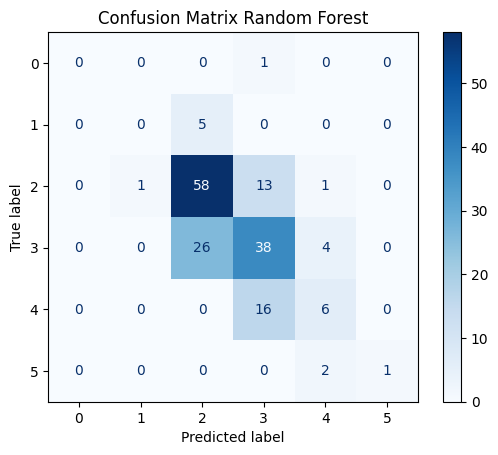

In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Membuat model
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Training model
model.fit(X_train, y_train)

# Prediksi data validation
y_pred = model.predict(X_valid)

# Accuracy
accuracy = accuracy_score(y_valid, y_pred)

print("Accuracy :", accuracy)

print("\nClassification Report")
print(classification_report(y_valid, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_valid, y_pred)

# Menampilkan confusion matrix dalam bentuk gambar
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title('Confusion Matrix Random Forest')
plt.show()

# Optimasi Model Random Forest

Dilakukan tuning parameter pada Random Forest untuk meningkatkan performa klasifikasi pada data validation.

Accuracy : 0.6453488372093024

Classification Report
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.70      0.78      0.74        73
           6       0.60      0.68      0.63        68
           7       0.57      0.36      0.44        22
           8       0.00      0.00      0.00         3

    accuracy                           0.65       172
   macro avg       0.31      0.30      0.30       172
weighted avg       0.61      0.65      0.62       172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


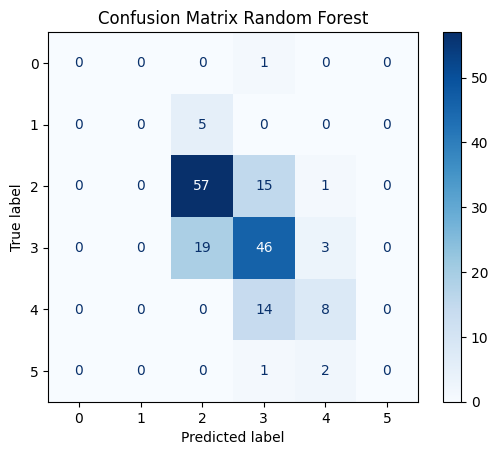

In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Model Random Forest yang dituning
model = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

# Training model
model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_valid)

# Accuracy
accuracy = accuracy_score(y_valid, y_pred)

print("Accuracy :", accuracy)

print("\nClassification Report")
print(classification_report(y_valid, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_valid, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title('Confusion Matrix Random Forest')
plt.show()

# Training Final Model

Model terbaik yang diperoleh kemudian dilatih kembali menggunakan seluruh data training sebelum digunakan untuk memprediksi data testing.

In [43]:
from sklearn.ensemble import RandomForestClassifier

# Final model
final_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

# Training menggunakan seluruh data training
final_model.fit(X, y)

RandomForestClassifier(max_depth=20, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=500, random_state=42)

# Pembuatan File Submission

Hasil prediksi disimpan dalam format CSV sesuai ketentuan soal, yaitu hanya memuat kolom Id dan quality.

In [45]:
final_pred = final_model.predict(X_test_final)

print(final_pred[:10])

[5 6 5 5 5 6 5 5 6 5]


In [47]:
submission = pd.DataFrame({
    'Id': test['Id'],
    'quality': final_pred
})

submission.head()

,Id,quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,5


# Export Hasil Prediksi

Hasil prediksi disimpan ke dalam file CSV sesuai format pengumpulan yang ditentukan pada soal.

In [48]:
submission.to_csv('hasilprediksi_062.csv', index=False)

print("File berhasil disimpan")

File berhasil disimpan


In [50]:
from google.colab import files

files.download('hasilprediksi_062.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>